# Import 



In [18]:
import yfinance as yf
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import talib
from datetime import datetime
import xgboost as xgb
from sklearn.metrics import confusion_matrix, accuracy_score, classification_report
import shap
from sklearn.model_selection import RandomizedSearchCV
import scipy.stats as stats
from statsmodels.graphics.tsaplots import plot_acf
from sklearn.feature_selection import mutual_info_classif
from xgboost import XGBClassifier
from sklearn.model_selection import TimeSeriesSplit, RandomizedSearchCV
from sklearn.metrics import classification_report, accuracy_score, confusion_matrix
import shap
import matplotlib.pyplot as plt
import optuna
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score, roc_auc_score
from optuna.samplers import TPESampler
from sklearn.preprocessing import LabelEncoder
from sklearn.model_selection import learning_curve
from sklearn.utils.class_weight import compute_sample_weight

from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import learning_curve
from sklearn.metrics import (
    f1_score, 
    accuracy_score, 
    classification_report, 
    confusion_matrix, 
    roc_auc_score, 
    precision_score, 
    recall_score
)
from sklearn.model_selection import learning_curve, TimeSeriesSplit
from sklearn.base import clone

# Download stock data



In [2]:

stock = 'NVDA'
# W projekcie zastosowano ceny skorygowane (auto_adjust=True), aby wyeliminować nieciągłości wynikające ze splitów i dywidend.
df = yf.download(stock, start='2017-01-01', end='2026-01-01', auto_adjust = True)

df.columns = df.columns.get_level_values(0)
df['Volume'] = df['Volume'].astype(float)
#Posortowanie po dacie, aby miec pewnosc ze dane sa chronologiczne
df = df.sort_index()
assert df.index.is_monotonic_increasing
# Upewnienie się, że nie mam pustych dni (np. weekend, święta)
df.isna().sum()


[*********************100%***********************]  1 of 1 completed


Price
Close     0
High      0
Low       0
Open      0
Volume    0
dtype: int64

In [3]:
df.head()

Price,Close,High,Low,Open,Volume
Date,,,,,
2017-01-03,2.512207,2.619581,2.447437,2.571065,1.501996e+09
2017-01-04,2.570819,2.598155,2.500386,2.546438,1.199220e+09
2017-01-05,2.505558,2.606036,2.488565,2.574268,9.842960e+08
2017-01-06,2.539051,2.567372,2.492259,2.532894,8.228560e+08
2017-01-09,2.641992,2.659723,2.548901,2.548901,9.162480e+08


# Wskaźniki giełdowe


# 2. Data Leakage handling
Na potrzeby pracy:
W dniu n model zna dane rynkowe z dnia n (po zamknięciu), a przewiduje ruch w przyszłości (n+1..n+h). Wszystkie cechy są konstruowane wyłącznie z danych historycznych ≤ n

## 3. Inżynieria Cech (Feature Engineering) i Etykietowanie Danych

In [4]:
# Przygotowanie danych do TA-Lib

close = df['Close'].to_numpy(dtype=float)
high  = df['High'].to_numpy(dtype=float)
low   = df['Low'].to_numpy(dtype=float)
volume = df['Volume'].to_numpy(dtype=float)


# ============================================================
# 2. FEATURE ENGINEERING (as-of t, EOD)
# ============================================================

# --- Returns (log) ---
df['Returns'] = np.log(df['Close'] / df['Close'].shift(1))
# używa Close(t) i Close(t-1) → OK w EOD

# --- Momentum / Trend ---
df['RSI'] = talib.RSI(close, timeperiod=14)
df['ADX'] = talib.ADX(high, low, close, timeperiod=14)

# MACD histogram (momentum, nie poziom)
_, _, df['MACD_hist'] = talib.MACD(
    close, fastperiod=12, slowperiod=26, signalperiod=9
)

# --- Volatility ---
df['ATR_Relative'] = talib.ATR(high, low, close, timeperiod=14) / df['Close']

# --- Distance-to-average (relative, no scale issues) ---
sma20 = talib.SMA(close, timeperiod=20)
ema50 = talib.EMA(close, timeperiod=50)

df['Dist_SMA_20'] = (df['Close'] - sma20) / sma20
df['Dist_EMA_50'] = (df['Close'] - ema50) / ema50

# --- Bollinger Bands (relative info only) ---
upper, middle, lower = talib.BBANDS(close, timeperiod=20)
df['BB_Width'] = (upper - lower) / middle
df['Percent_BB'] = (df['Close'] - lower) / (upper - lower)

# --- Volume & Flow ---
df['Relative_Volume'] = df['Volume'] / df['Volume'].rolling(window=20).mean()
# rolling mean do dnia t → OK

df['CMF'] = talib.ADOSC(
    high, low, close, volume, fastperiod=3, slowperiod=10
)

df['ROC_10'] = talib.ROC(close, timeperiod=10)

# --- Market efficiency (trend vs noise) ---
direction = (df['Close'] - df['Close'].shift(10)).abs()
volatility = (df['Close'] - df['Close'].shift(1)).abs().rolling(10).sum()
df['Efficiency_Ratio'] = direction / (volatility + 1e-10)

# --- Cycles ---
df['HT_Period'] = talib.HT_DCPERIOD(close)

# --- Calendar & gap ---
df['DayOfWeek'] = df.index.dayofweek

df['Gap'] = (df['Open'] - df['Close'].shift(1)) / df['Close'].shift(1)
# Gap(t) znany dopiero po otwarciu dnia t → OK przy EOD

# --- 3. TRIPLE BARRIER METHOD (TARGET) ---
def get_tbm_labels(price_series, returns_series, days=5, vol_mult=1.5):
    vol = returns_series.rolling(window=20).std()
    labels = []

    for i in range(len(price_series) - days):
        p_now = price_series.iloc[i]
        sigma = vol.iloc[i]

        if pd.isna(sigma):
            labels.append(0)
            continue

        b_up = p_now * (1 + sigma * vol_mult)
        b_down = p_now * (1 - sigma * vol_mult)

        future = price_series.iloc[i+1 : i+days+1]

        hit_up = future[future >= b_up].index.min()
        hit_down = future[future <= b_down].index.min()

        if pd.isna(hit_up) and pd.isna(hit_down):
            labels.append(0)
        elif pd.isna(hit_down) or (hit_up is not None and hit_up < hit_down):
            labels.append(1)
        else:
            labels.append(-1)

    labels.extend([0] * days)
    return labels

df['Target'] = get_tbm_labels(df['Close'], df['Returns'])


# 4. Usuwanie surowych cen (zostają tylko cechy)
raw_cols = ['Open', 'High', 'Low', 'Close', 'Volume']
df_final = df.drop(columns=raw_cols).copy()

# --- Usuwamy NaN po wskaźnikach ---
df_final = df_final.dropna().copy()

# sanity check
assert df_final.index.is_monotonic_increasing

print("Gotowe dane:")
print("Shape:", df_final.shape)
print("\nRozkład klas Target:")
print(df_final['Target'].value_counts(normalize=True))

df_final[['Returns', 'RSI', 'MACD_hist', 'Target']].head(10)



Gotowe dane:
Shape: (2213, 17)

Rozkład klas Target:
Target
 1    0.395843
 0    0.319476
-1    0.284681
Name: proportion, dtype: float64


Price,Returns,RSI,MACD_hist,Target
Date,,,,
2017-03-15,0.007537,48.046105,0.002077,1
2017-03-16,0.012212,51.008641,0.008111,1
2017-03-17,0.021537,55.869349,0.015419,0
2017-03-20,0.031369,61.949891,0.024871,0
2017-03-21,-0.032878,53.617391,0.024225,0
2017-03-22,0.020190,57.383955,0.026197,0
2017-03-23,-0.009110,55.193961,0.024707,0
2017-03-24,0.003542,55.896820,0.023208,0
2017-03-27,0.007231,57.374819,0.022359,0


# 3 SPLIT danych na treningowe, do walidacji  i testowe

In [5]:
df_final = df_final.sort_index().copy()
assert df_final.index.is_monotonic_increasing

# Proporcje 
train_ratio = 0.70
val_ratio   = 0.15  # reszta = test

n = len(df_final)
train_end = int(n * train_ratio)
val_end   = int(n * (train_ratio + val_ratio))

train_df = df_final.iloc[:train_end].copy()
val_df   = df_final.iloc[train_end:val_end].copy()
test_df  = df_final.iloc[val_end:].copy()

print(" Split sizes:")
print("Train:", train_df.shape, "|", train_df.index.min().date(), "->", train_df.index.max().date())
print("Val  :", val_df.shape,   "|", val_df.index.min().date(), "->", val_df.index.max().date())
print("Test :", test_df.shape,  "|", test_df.index.min().date(), "->", test_df.index.max().date())

print("\n Target distribution (train/val/test):")
print("Train:\n", train_df['Target'].value_counts(normalize=True))
print("\nVal:\n", val_df['Target'].value_counts(normalize=True))
print("\nTest:\n", test_df['Target'].value_counts(normalize=True))

 Split sizes:
Train: (1549, 17) | 2017-03-15 -> 2023-05-09
Val  : (332, 17) | 2023-05-10 -> 2024-09-04
Test : (332, 17) | 2024-09-05 -> 2025-12-31

 Target distribution (train/val/test):
Train:
 Target
 1    0.391220
 0    0.326017
-1    0.282763
Name: proportion, dtype: float64

Val:
 Target
 1    0.448795
 0    0.280120
-1    0.271084
Name: proportion, dtype: float64

Test:
 Target
 1    0.364458
 0    0.328313
-1    0.307229
Name: proportion, dtype: float64



## 3. Inżynieria Cech i Zaawansowane EDA (Metodologia)
Przeprowadzam sekcej EDA na danych Testowych


Missing values in TRAIN (top 15):
Price
Returns             0
RSI                 0
ADX                 0
MACD_hist           0
ATR_Relative        0
Dist_SMA_20         0
Dist_EMA_50         0
BB_Width            0
Percent_BB          0
Relative_Volume     0
CMF                 0
ROC_10              0
Efficiency_Ratio    0
HT_Period           0
DayOfWeek           0
dtype: int64

 Train head preview:


Price,Returns,RSI,ADX,MACD_hist,ATR_Relative,Dist_SMA_20,Dist_EMA_50,BB_Width,Percent_BB,Relative_Volume,CMF,ROC_10,Efficiency_Ratio,HT_Period,DayOfWeek,Gap,Target
Date,,,,,,,,,,,,,,,,,
2017-03-15,0.007537,48.046105,25.401573,0.002077,0.032584,-0.000308,-0.033375,0.161199,0.498088,0.899721,3.924419e+08,-0.233517,0.022774,26.748900,2,0.004618,1
2017-03-16,0.012212,51.008641,24.174715,0.008111,0.030866,0.014473,-0.020672,0.152043,0.595191,0.756921,5.740988e+08,4.858582,0.600505,27.197404,3,0.004193,1
2017-03-17,0.021537,55.869349,22.610371,0.015419,0.029607,0.037088,0.000622,0.149851,0.747498,1.566622,9.370635e+08,7.761837,0.787638,27.648082,4,0.006839,0
2017-03-20,0.031369,61.949891,22.116592,0.024871,0.028953,0.068905,0.031194,0.156644,0.939883,1.033996,1.216640e+09,12.061000,0.956174,27.783306,0,0.006694,0
2017-03-21,-0.032878,53.617391,21.473166,0.024225,0.030731,0.036874,-0.002074,0.141148,0.761247,1.231056,9.723206e+08,7.261481,0.484788,27.719497,1,-0.006396,0


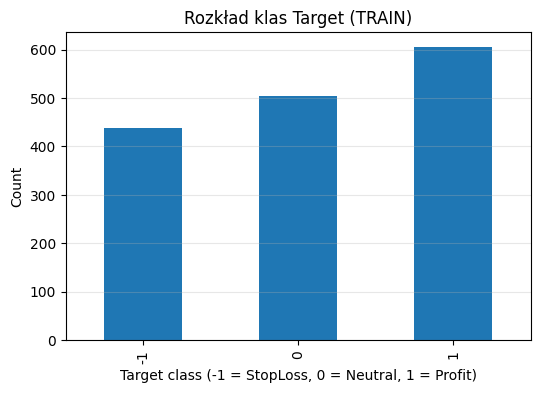

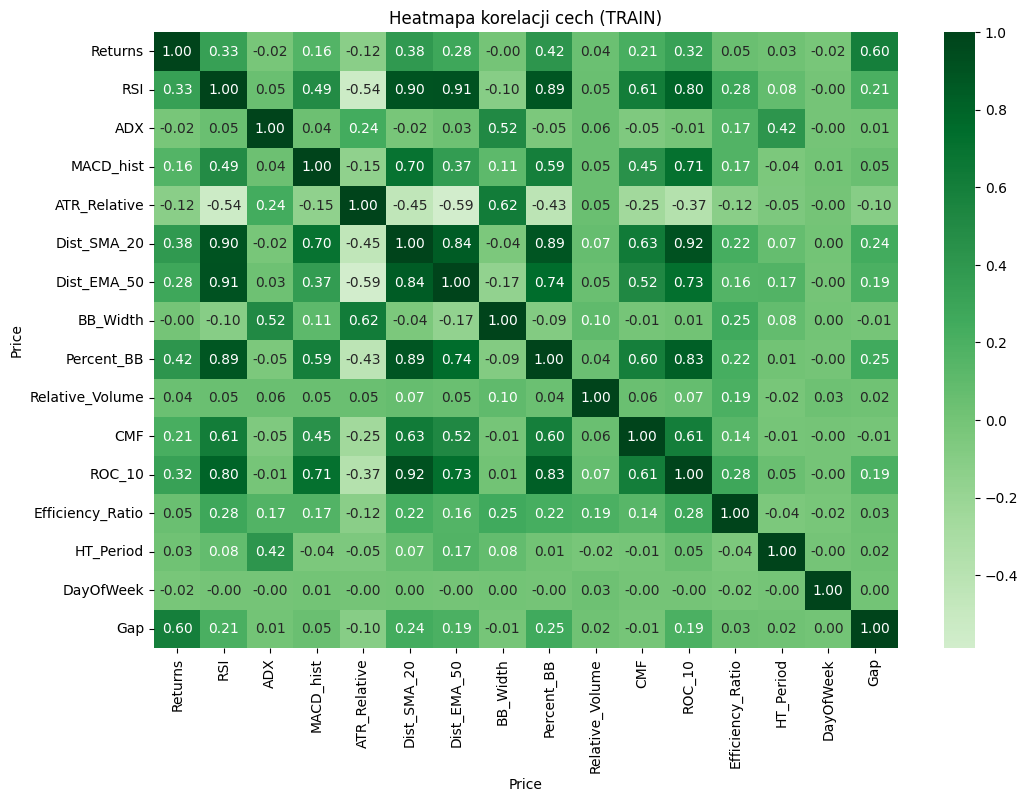


 Shapes: 
Train: (1549, 17)
Val  : (332, 17)
Test : (332, 17)


In [6]:
print("Missing values in TRAIN (top 15):")
print(train_df.isna().sum().sort_values(ascending=False).head(15))

print("\n Train head preview:")
display(train_df.head())

# Target counts
plt.figure(figsize=(6, 4))
train_df['Target'].value_counts().sort_index().plot(kind='bar')
plt.title("Rozkład klas Target (TRAIN)")
plt.xlabel("Target class (-1 = StopLoss, 0 = Neutral, 1 = Profit)")
plt.ylabel("Count")
plt.grid(axis='y', alpha=0.3)
plt.show()

X_train = train_df.drop(columns=['Target']).copy()

corr = X_train.corr()

plt.figure(figsize=(12, 8))
sns.heatmap(
    corr,
    cmap='Greens',      # zielona paleta
    center=0,
    annot=True,         # pokazuje liczby
    fmt=".2f"           # format liczb
)
plt.title("Heatmapa korelacji cech (TRAIN)")
plt.show()



print("\n Shapes: ")
print("Train:", train_df.shape)
print("Val  :", val_df.shape)
print("Test :", test_df.shape)

## Usunięcie korelacji > 80

 Features to drop due to correlation > 0.8 (based on TRAIN only):
['Dist_SMA_20', 'Dist_EMA_50', 'Percent_BB', 'ROC_10']


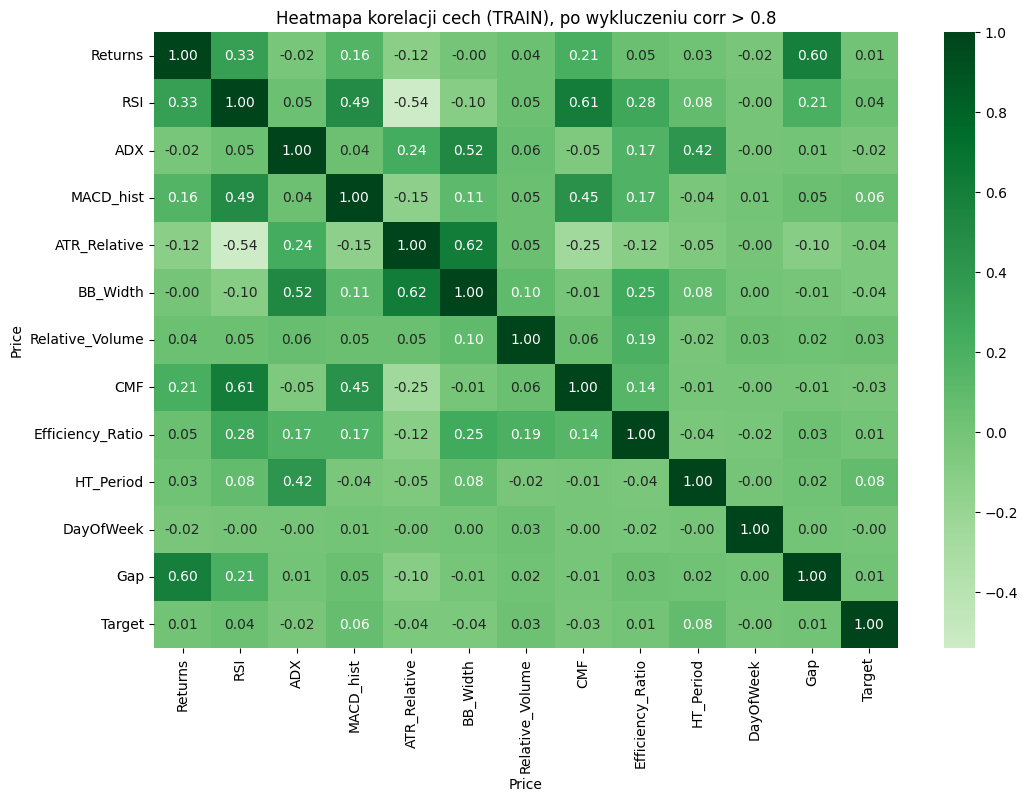

In [7]:
threshold = 0.8 # ile musi wyniesc korelacja by je wykluczyć
corr_abs = X_train.corr().abs()
upper = corr_abs.where(np.triu(np.ones(corr_abs.shape), k=1).astype(bool))

to_drop = [col for col in upper.columns if any(upper[col] > threshold)]
print(f" Features to drop due to correlation > {threshold} (based on TRAIN only):")
print(to_drop)

# Apply same drops to train/val/test to avoid leakage
train_df_filtered = train_df.drop(columns=to_drop)
val_df_filtered   = val_df.drop(columns=to_drop)
test_df_filtered  = test_df.drop(columns=to_drop)




corr = train_df_filtered.corr()

plt.figure(figsize=(12, 8))
sns.heatmap(
    corr,
    cmap='Greens',      # zielona paleta
    center=0,
    annot=True,         # pokazuje liczby
    fmt=".2f"           # format liczb
)
plt.title("Heatmapa korelacji cech (TRAIN), po wykluczeniu corr > 0.8")
plt.show()

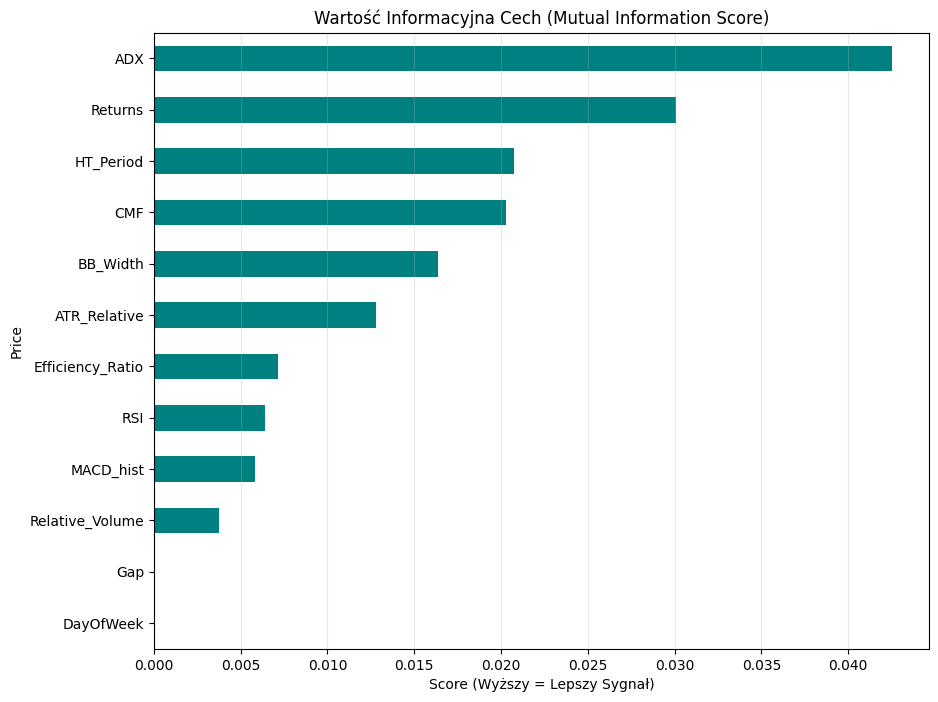

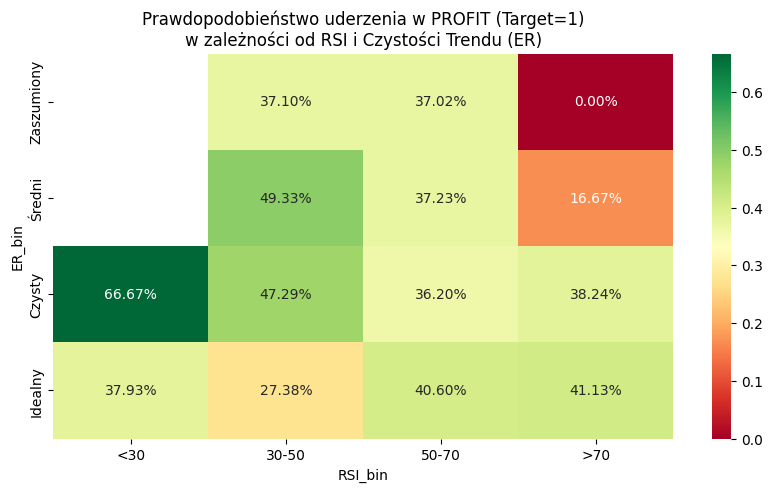

<Figure size 1000x400 with 0 Axes>

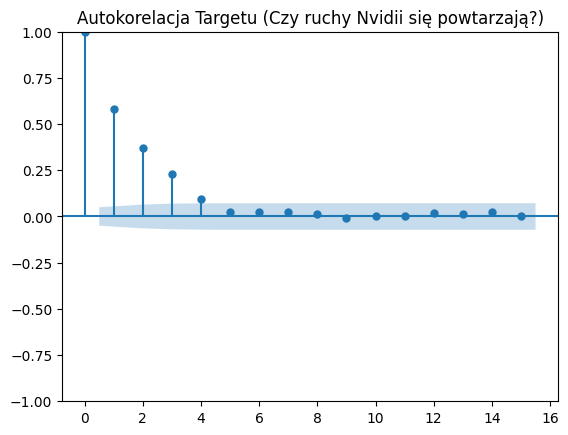

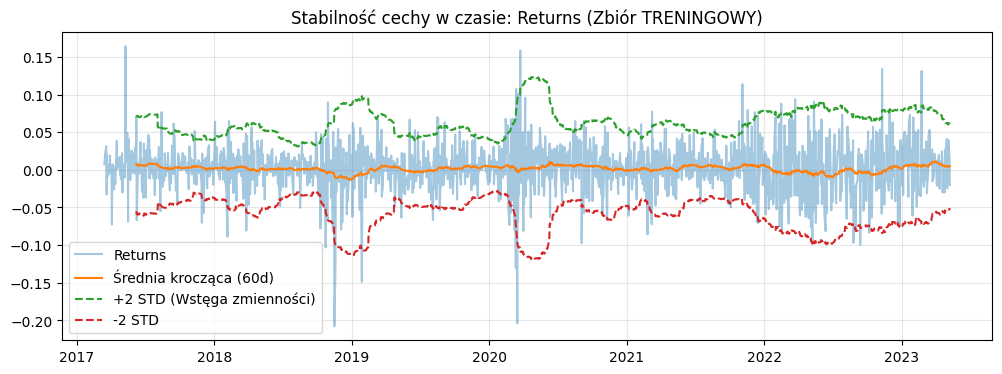

In [8]:

#   1. Mutual Information (Która cecha faktycznie wpływa na Target?) 
X_eda = train_df_filtered.drop(columns=['Target'])
y_eda = train_df_filtered['Target']
mi_scores = mutual_info_classif(X_eda, y_eda, discrete_features=False, random_state=42)

mi_series = pd.Series(mi_scores, index=X_eda.columns).sort_values(ascending=True)

plt.figure(figsize=(10, 8))
mi_series.plot(kind='barh', color='teal')
plt.title("Wartość Informacyjna Cech (Mutual Information Score)")
plt.xlabel("Score (Wyższy = Lepszy Sygnał)")
plt.grid(axis='x', alpha=0.3)
plt.show()

#  2. HEATMAPA PRAWDOPODOBIEŃSTWA (Strategia TBM) 
# Analizujemy, kiedy szansa na Profit (Target=1) jest największa
temp_df = train_df_filtered.copy()
temp_df['RSI_bin'] = pd.cut(temp_df['RSI'], bins=[0, 30, 50, 70, 100], labels=['<30', '30-50', '50-70', '>70'])
temp_df['ER_bin'] = pd.qcut(temp_df['Efficiency_Ratio'], q=4, labels=['Zaszumiony', 'Średni', 'Czysty', 'Idealny'])

prob_table = temp_df[temp_df['Target'] == 1].groupby(['ER_bin', 'RSI_bin'], observed=False).size() / \
             temp_df.groupby(['ER_bin', 'RSI_bin'], observed=False).size()

plt.figure(figsize=(10, 5))
sns.heatmap(prob_table.unstack(), annot=True, cmap='RdYlGn', fmt='.2%')
plt.title('Prawdopodobieństwo uderzenia w PROFIT (Target=1)\nw zależności od RSI i Czystości Trendu (ER)')
plt.show()

#  3. ANALIZA AUTOKORELACJI (ACF) 
# Sprawdzamy, czy rynek ma "pamięć" (czy wczorajszy ruch wpływa na dzisiejszy)
plt.figure(figsize=(10, 4))
plot_acf(train_df_filtered['Target'], lags=15)
plt.title("Autokorelacja Targetu (Czy ruchy Nvidii się powtarzają?)")
plt.show()

#  4. STABILNOŚĆ CECHY W CZASIE (Feature Drift) 
# Sprawdzamy, czy charakterystyka zwrotów nie zmienia się drastycznie
feature_to_plot = 'Returns'  

rolling_mean = train_df_filtered[feature_to_plot].rolling(60).mean()
rolling_std  = train_df_filtered[feature_to_plot].rolling(60).std()

plt.figure(figsize=(12, 4))
plt.plot(train_df_filtered.index, train_df_filtered[feature_to_plot], alpha=0.4, label=feature_to_plot)
plt.plot(train_df_filtered.index, rolling_mean, label="Średnia krocząca (60d)")
plt.plot(train_df_filtered.index, rolling_mean + 2*rolling_std, linestyle='--', label="+2 STD (Wstęga zmienności)")
plt.plot(train_df_filtered.index, rolling_mean - 2*rolling_std, linestyle='--', label="-2 STD")
plt.title(f"Stabilność cechy w czasie: {feature_to_plot} (Zbiór TRENINGOWY)")
plt.legend()
plt.grid(alpha=0.3)
plt.show()

# 5. Przygotowanie finalnego DataSet

In [9]:
# --- 1. Przygotowanie listy cech do wyrzucenia na podstawie MI ---
# Wybieramy cechy, których MI Score jest bliski zeru 
weak_features = mi_series[mi_series < 0.005].index.tolist()
print("Cechy do usunięcia (niski MI score):", weak_features)

# --- TARGETY (Wspólne dla obu wersji) ---
y_train = train_df_filtered['Target']
y_val   = val_df_filtered['Target']
y_test  = test_df_filtered['Target']

# --- 2. DATASET V1: Tylko po korelacji (Filtered) ---
X_train_v1 = train_df_filtered.drop(columns=['Target'])
X_val_v1   = val_df_filtered.drop(columns=['Target'])
X_test_v1  = test_df_filtered.drop(columns=['Target'])

# --- 3. DATASET V2: Korelacja + MI Selection (Smart) ---
X_train_v2 = X_train_v1.drop(columns=weak_features)
X_val_v2   = X_val_v1.drop(columns=weak_features)
X_test_v2  = X_test_v1.drop(columns=weak_features)

print("\n--- FINALNE KSZTAŁTY ---")
print(f"V1 (Tylko korelacja): {X_train_v1.shape[1]} cech")
print(f"V2 (Korelacja + MI):  {X_train_v2.shape[1]} cech")
print(f"Targety: Train={len(y_train)}, Val={len(y_val)}, Test={len(y_test)}")

Cechy do usunięcia (niski MI score): ['DayOfWeek', 'Gap', 'Relative_Volume']

--- FINALNE KSZTAŁTY ---
V1 (Tylko korelacja): 12 cech
V2 (Korelacja + MI):  9 cech
Targety: Train=1549, Val=332, Test=332


In [26]:

# Mapowanie: -1 -> 0, 0 -> 1, 1 -> 2
le = LabelEncoder()
y_train_encoded = le.fit_transform(y_train)
y_val_encoded = le.transform(y_val)
y_test_encoded = le.transform(y_test)

sample_weights = compute_sample_weight(class_weight='balanced', y=y_train_encoded)

print("Klasy:", le.classes_)
print("Mapping gotowy.")

# Funckaj wykresu - 
def plot_overfitting_analysis(model, X, y, title):
    from sklearn.model_selection import learning_curve, TimeSeriesSplit
    from xgboost import XGBClassifier
    import numpy as np
    import matplotlib.pyplot as plt

    # 1. Automatyczne przygotowanie modelu pod wykres
    if isinstance(model, XGBClassifier):
        # Specyficzne czyszczenie dla XGBoost, aby learning_curve nie wywalił błędu
        current_params = model.get_params()
        for p in ['early_stopping_rounds', 'callbacks', 'eval_metric']:
            current_params.pop(p, None)
        model_to_plot = XGBClassifier(**current_params)
    else:
        # Standardowe klonowanie dla innych modeli (np. Random Forest)
        model_to_plot = clone(model)

    # 2. Obliczenia (jednakowe dla wszystkich)
    tscv = TimeSeriesSplit(n_splits=3)
    train_sizes, train_scores, test_scores = learning_curve(
        model_to_plot, X, y, cv=tscv, n_jobs=-1, 
        train_sizes=np.linspace(0.1, 1.0, 5),
        scoring='accuracy'
    )
    
    train_mean = np.mean(train_scores, axis=1)
    test_mean = np.mean(test_scores, axis=1)

    # 3. Rysowanie (Styl Premium, skala 0-1)
    plt.figure(figsize=(10, 5))
    plt.plot(train_sizes, train_mean, 'o-', linewidth=2, label="Train (Trening)")
    plt.plot(train_sizes, test_mean, 's-', linewidth=2, label="Val (Walidacja)")
    
    plt.ylim(0, 1.05) 
    plt.title(title, fontsize=14, pad=15)
    plt.xlabel("Liczba próbek w treningu")
    plt.ylabel("Accuracy (0.0 - 1.0)")
    plt.axhline(y=1.0, color='gray', linestyle='--', alpha=0.3)
    plt.legend(loc="lower right", frameon=True, shadow=True)
    plt.grid(True, linestyle='--', alpha=0.7)
    plt.tight_layout()
    plt.show()
    
    # Bonus: szybki raport tekstowy pod wykresem
    print(f"Ostatnie Accuracy - Train: {train_mean[-1]:.4f}, Val: {test_mean[-1]:.4f}")
    print(f"Gap (Overfitting): {abs(train_mean[-1] - test_mean[-1]):.4f}")

Klasy: [-1  0  1]
Mapping gotowy.


## 4. 1. Model XGBoost - dataset V1 - tylko usunięcie korelacji


In [42]:
# --- 1. PRZYGOTOWANIE POŁĄCZONYCH DANYCH ---
# Łączymy Train i Val, żeby model miał więcej danych do nauki wewnątrz CV
X_full_v1 = np.concatenate([X_train_v1, X_val_v1])
y_full_v1 = np.concatenate([y_train_encoded, y_val_encoded])

def objective_v1_cv(trial):
    param = {
        'objective': 'multi:softprob', 'num_class': 3, 'eval_metric': 'mlogloss',
        'n_estimators': 500, 
        'learning_rate': trial.suggest_float('learning_rate', 0.01, 0.1, log=True),
        'max_depth': trial.suggest_int('max_depth', 2, 6),
        'min_child_weight': trial.suggest_int('min_child_weight', 10, 50),
        'subsample': trial.suggest_float('subsample', 0.6, 0.9),
        'colsample_bytree': trial.suggest_float('colsample_bytree', 0.6, 0.9),
        'n_jobs': -1, 'random_state': 42
    }
    
    tscv = TimeSeriesSplit(n_splits=3)
    cv_scores = []

    for train_idx, val_idx in tscv.split(X_full_v1):
        X_t, X_v = X_full_v1[train_idx], X_full_v1[val_idx]
        y_t, y_v = y_full_v1[train_idx], y_full_v1[val_idx]
        
        model = xgb.XGBClassifier(**param)
        model.fit(X_t, y_t, verbose=False)
        
        preds = model.predict(X_v)
        cv_scores.append(f1_score(y_v, preds, average='macro'))
    
    return np.mean(cv_scores)

# --- 2. OPTYMALIZACJA ---
print(">>> Start Optymalizacji V1 (TimeSeries CV)...")
study_v1 = optuna.create_study(direction='maximize', sampler=TPESampler(seed=42))

study_v1.optimize(objective_v1_cv, n_trials=100) 

# --- 3. FINALNY TRENING NA PEŁNYM ZBIORZE ---
best_params_v1 = study_v1.best_params
best_params_v1.update({'objective': 'multi:softprob', 'num_class': 3, 'n_estimators': 2000})
xgb_v1 = xgb.XGBClassifier(**best_params_v1)

# Trenujemy na WSZYSTKICH danych (Train + Val), żeby na test wyjść z najbogatszą wiedzą
xgb_v1.fit(X_full_v1, y_full_v1, verbose=100)

print("Model V1 (CV) Gotowy!")

[I 2026-02-02 21:42:36,307] A new study created in memory with name: no-name-632de0d0-eea5-4458-b188-1fe20e65c49c


>>> Start Optymalizacji V1 (TimeSeries CV)...


[I 2026-02-02 21:42:37,051] Trial 0 finished with value: 0.3700717280358992 and parameters: {'learning_rate': 0.023688639503640783, 'max_depth': 6, 'min_child_weight': 40, 'subsample': 0.779597545259111, 'colsample_bytree': 0.6468055921327309}. Best is trial 0 with value: 0.3700717280358992.
[I 2026-02-02 21:42:37,538] Trial 1 finished with value: 0.36015678510605853 and parameters: {'learning_rate': 0.01432169828911152, 'max_depth': 2, 'min_child_weight': 45, 'subsample': 0.7803345035229626, 'colsample_bytree': 0.8124217733388137}. Best is trial 0 with value: 0.3700717280358992.
[I 2026-02-02 21:42:38,228] Trial 2 finished with value: 0.35025263521968103 and parameters: {'learning_rate': 0.010485387725194618, 'max_depth': 6, 'min_child_weight': 44, 'subsample': 0.6637017332034828, 'colsample_bytree': 0.6545474901621302}. Best is trial 0 with value: 0.3700717280358992.
[I 2026-02-02 21:42:38,836] Trial 3 finished with value: 0.3717306962722149 and parameters: {'learning_rate': 0.015254

Model V1 (CV) Gotowy!


## 5. 1.1 Model XGBoost - dataset V2- usunięcie korelacji, usunięcię Mutual Information <0.005



In [44]:
# --- 1. PRZYGOTOWANIE POŁĄCZONYCH DANYCH V2 ---
X_full_v2 = np.concatenate([X_train_v2, X_val_v2])
y_full_v2 = np.concatenate([y_train_encoded, y_val_encoded])

def objective_v2_cv(trial):
    param = {
        'objective': 'multi:softprob', 
        'num_class': 3, 
        'eval_metric': 'mlogloss',
        'n_estimators': 500, 
        'n_jobs': -1, 
        'random_state': 42,
        # Szersze zakresy dla V2 (Smart Selection często lubi głębsze drzewa lub wyższy LR)
        'learning_rate': trial.suggest_float('learning_rate', 0.005, 0.1, log=True),
        'max_depth': trial.suggest_int('max_depth', 2, 8),
        'min_child_weight': trial.suggest_int('min_child_weight', 5, 40),
        'subsample': trial.suggest_float('subsample', 0.5, 0.9),
        'colsample_bytree': trial.suggest_float('colsample_bytree', 0.5, 0.9),
        'reg_alpha': trial.suggest_float('reg_alpha', 1e-2, 10.0, log=True),
        'reg_lambda': trial.suggest_float('reg_lambda', 1e-2, 10.0, log=True),
    }
    
    tscv = TimeSeriesSplit(n_splits=3)
    cv_scores = []

    for train_idx, val_idx in tscv.split(X_full_v2):
        X_t, X_v = X_full_v2[train_idx], X_full_v2[val_idx]
        y_t, y_v = y_full_v2[train_idx], y_full_v2[val_idx]
        
        model = xgb.XGBClassifier(**param)
        model.fit(X_t, y_t, verbose=False)
        
        preds = model.predict(X_v)
        # Optymalizujemy pod F1 Macro tak jak w V1!
        cv_scores.append(f1_score(y_v, preds, average='macro'))
    
    return np.mean(cv_scores)

# --- 2. OPTYMALIZACJA V2 ---
print(">>> Start Optymalizacji V2 (TimeSeries CV + Smart Selection)...")
study_v2 = optuna.create_study(direction='maximize', sampler=TPESampler(seed=42))
study_v2.optimize(objective_v2_cv, n_trials=100) 

# --- 3. FINALNY TRENING V2 ---
best_params_v2 = study_v2.best_params
best_params_v2.update({'objective': 'multi:softprob', 'num_class': 3, 'n_estimators': 2000})

xgb_v2 = xgb.XGBClassifier(**best_params_v2)
# Trenujemy na pełnym połączonym zbiorze V2
xgb_v2.fit(X_full_v2, y_full_v2, verbose=100)

print("Model V2 (CV) Gotowy!")

[I 2026-02-02 21:50:09,608] A new study created in memory with name: no-name-db4184c8-6332-4f11-8bfb-5adeabb79669


>>> Start Optymalizacji V2 (TimeSeries CV + Smart Selection)...


[I 2026-02-02 21:50:10,425] Trial 0 finished with value: 0.3589459392012027 and parameters: {'learning_rate': 0.015355286838886862, 'max_depth': 8, 'min_child_weight': 31, 'subsample': 0.7394633936788146, 'colsample_bytree': 0.5624074561769746, 'reg_alpha': 0.029375384576328288, 'reg_lambda': 0.014936568554617643}. Best is trial 0 with value: 0.3589459392012027.
[I 2026-02-02 21:50:11,076] Trial 1 finished with value: 0.36381995333360345 and parameters: {'learning_rate': 0.06697167353375243, 'max_depth': 6, 'min_child_weight': 30, 'subsample': 0.508233797718321, 'colsample_bytree': 0.8879639408647977, 'reg_alpha': 3.142880890840109, 'reg_lambda': 0.04335281794951567}. Best is trial 1 with value: 0.36381995333360345.
[I 2026-02-02 21:50:11,662] Trial 2 finished with value: 0.35136215045235947 and parameters: {'learning_rate': 0.008620446097910767, 'max_depth': 3, 'min_child_weight': 15, 'subsample': 0.7099025726528951, 'colsample_bytree': 0.6727780074568463, 'reg_alpha': 0.0747631206225

Model V2 (CV) Gotowy!


# Wykresy XGBoost dla V1 i V2


 XGBoost V1 vs V2

[RAPORT V1] Pełny Zestaw Cech
              precision    recall  f1-score   support

          -1       0.27      0.33      0.30       102
           0       0.45      0.27      0.34       109
           1       0.37      0.44      0.40       121

    accuracy                           0.35       332
   macro avg       0.37      0.35      0.35       332
weighted avg       0.37      0.35      0.35       332


[RAPORT V2] Smart Selection
              precision    recall  f1-score   support

          -1       0.27      0.34      0.30       102
           0       0.43      0.20      0.28       109
           1       0.36      0.45      0.40       121

    accuracy                           0.33       332
   macro avg       0.35      0.33      0.32       332
weighted avg       0.35      0.33      0.33       332



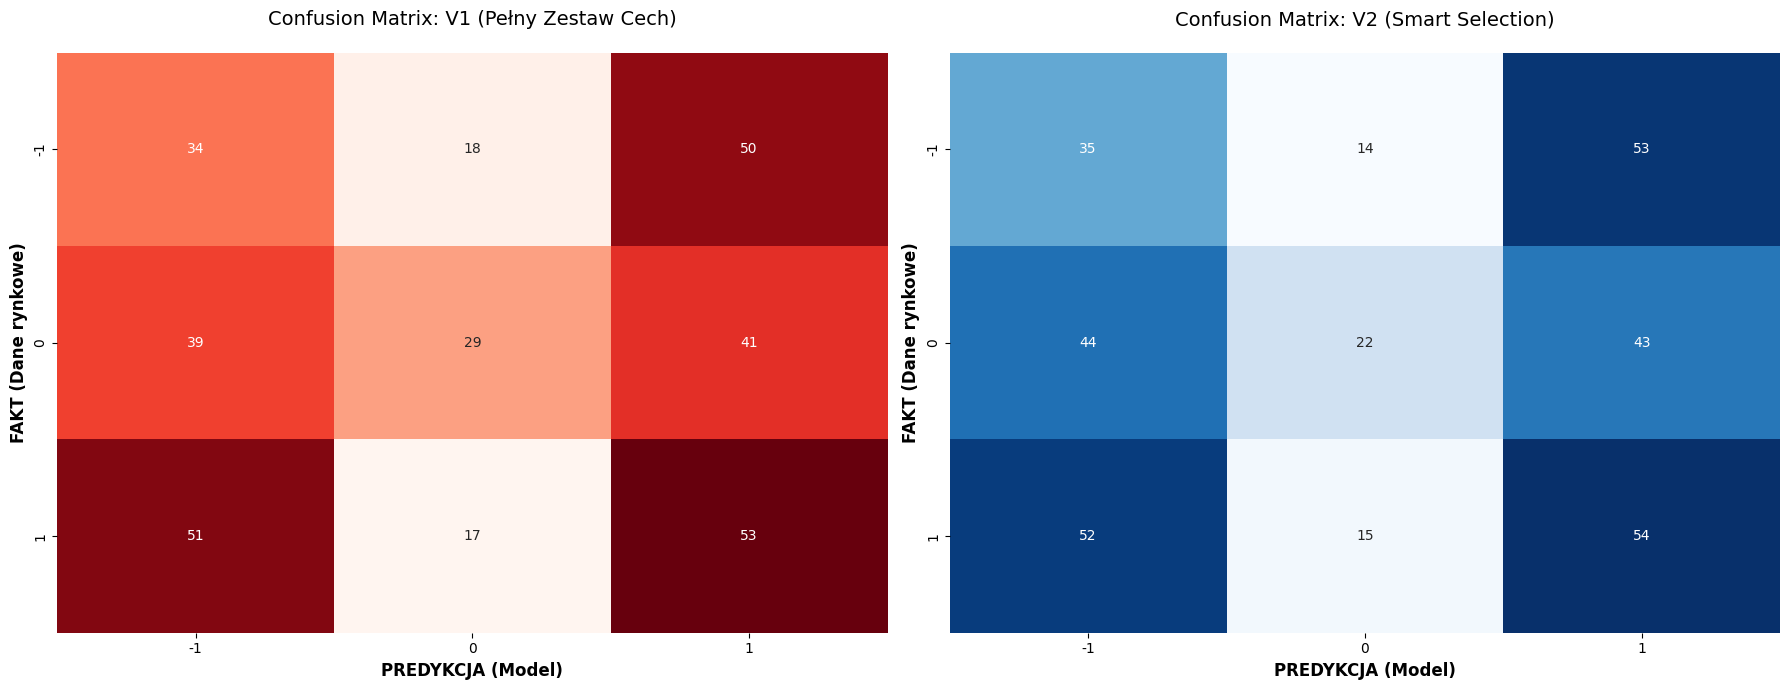

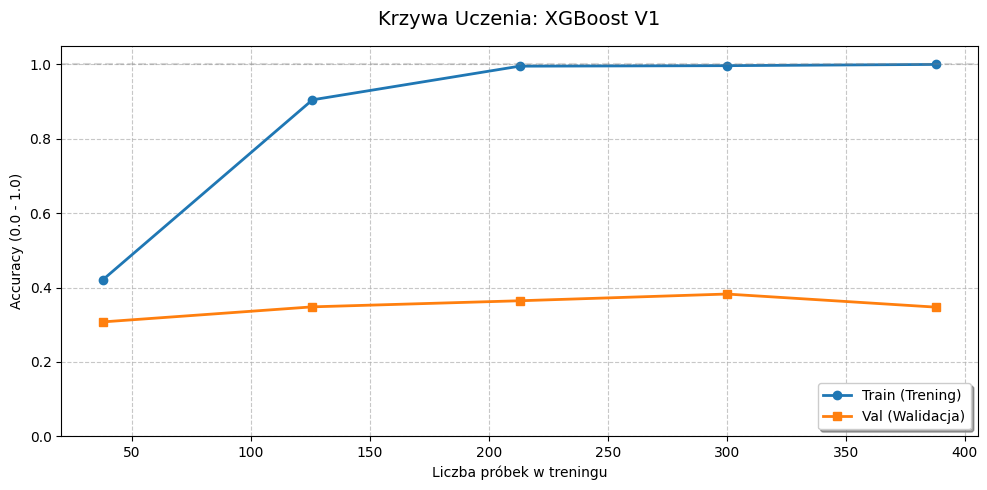

Ostatnie Accuracy - Train: 1.0000, Val: 0.3471
Gap (Overfitting): 0.6529


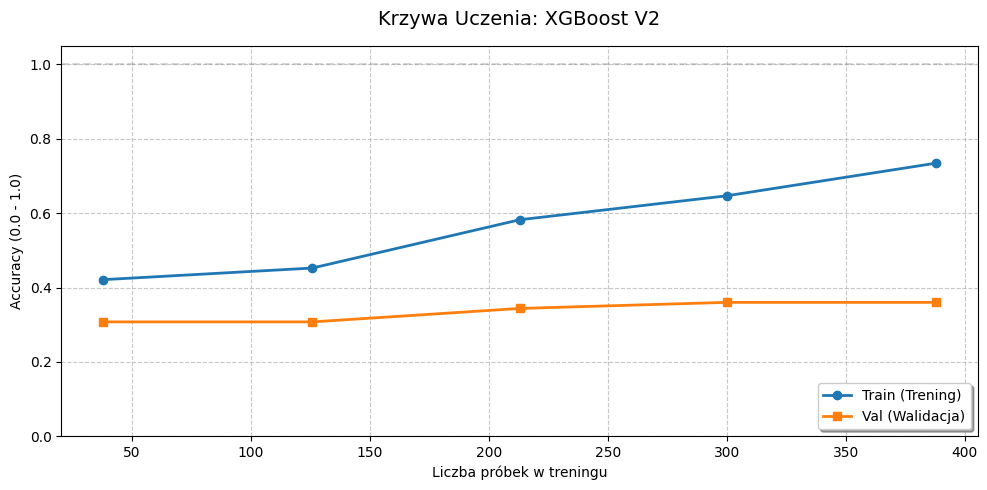

Ostatnie Accuracy - Train: 0.7345, Val: 0.3600
Gap (Overfitting): 0.3745


In [47]:
print("\n" + "="*60)
print(" XGBoost V1 vs V2")
print("="*60)

# --- 1. RAPORTY TEKSTOWE ---
print("\n[RAPORT V1] Pełny Zestaw Cech")
y_pred_v1 = xgb_v1.predict(X_test_v1)
print(classification_report(y_test_encoded, y_pred_v1, target_names=le.classes_.astype(str)))

print("\n[RAPORT V2] Smart Selection")
y_pred_v2 = xgb_v2.predict(X_test_v2)
print(classification_report(y_test_encoded, y_pred_v2, target_names=le.classes_.astype(str)))

# --- 2. CONFUSION MATRIX (Z poprawionymi etykietami osi) ---
fig, ax = plt.subplots(1, 2, figsize=(18, 7))

# V1 Matrix
cm_v1 = confusion_matrix(le.inverse_transform(y_test_encoded), le.inverse_transform(y_pred_v1), labels=le.classes_)
sns.heatmap(cm_v1, annot=True, fmt='d', cmap='Reds', ax=ax[0], 
            xticklabels=le.classes_, yticklabels=le.classes_, cbar=False)
ax[0].set_title('Confusion Matrix: V1 (Pełny Zestaw Cech)', fontsize=14, pad=20)
ax[0].set_xlabel('PREDYKCJA (Model)', fontsize=12, fontweight='bold')
ax[0].set_ylabel('FAKT (Dane rynkowe)', fontsize=12, fontweight='bold')

# V2 Matrix
cm_v2 = confusion_matrix(le.inverse_transform(y_test_encoded), le.inverse_transform(y_pred_v2), labels=le.classes_)
sns.heatmap(cm_v2, annot=True, fmt='d', cmap='Blues', ax=ax[1], 
            xticklabels=le.classes_, yticklabels=le.classes_, cbar=False)
ax[1].set_title('Confusion Matrix: V2 (Smart Selection)', fontsize=14, pad=20)
ax[1].set_xlabel('PREDYKCJA (Model)', fontsize=12, fontweight='bold')
ax[1].set_ylabel('FAKT (Dane rynkowe)', fontsize=12, fontweight='bold')

plt.tight_layout()
plt.show()
# --- 3. KRZYWE UCZENIA (Overfitting Analysis) ---
plot_overfitting_analysis(xgb_v1, X_train_v1, y_train_encoded, "Krzywa Uczenia: XGBoost V1")
plot_overfitting_analysis(xgb_v2, X_train_v2, y_train_encoded, "Krzywa Uczenia: XGBoost V2")

## 6. 1. Model RandomForest - dane V1- usunięta korelacja, dane V2 - usunięta korelacja i Mutual Information


In [70]:
# --- V1: PEŁNY ZESTAW + F1 MACRO + REGULARYZACJA ---
X_full_v1 = np.concatenate([X_train_v1, X_val_v1])
y_full = np.concatenate([y_train_encoded, y_val_encoded])

def objective_rf_v1(trial):
    params = {
        'n_estimators': trial.suggest_int('n_estimators', 200, 700), 
        'max_depth': trial.suggest_int('max_depth', 3, 12),
        'min_samples_leaf': trial.suggest_int('min_samples_leaf', 50, 150),
        'max_features': trial.suggest_categorical('max_features', ['sqrt', 'log2']),
        'bootstrap': True,
        'max_samples': trial.suggest_float('max_samples', 0.5, 0.9),
        'class_weight': 'balanced_subsample',
        'random_state': 42, 'n_jobs': -1
    }
    tscv = TimeSeriesSplit(n_splits=3)
    scores = []
    for train_idx, val_idx in tscv.split(X_full_v1):
        rf = RandomForestClassifier(**params).fit(X_full_v1[train_idx], y_full[train_idx])
        preds = rf.predict(X_full_v1[val_idx])
        # KLUCZ: Teraz V1 też walczy o F1 Macro!
        scores.append(f1_score(y_full[val_idx], preds, average='macro'))
    return np.mean(scores)

study_rf_v1 = optuna.create_study(direction='maximize')
study_rf_v1.optimize(objective_rf_v1, n_trials=50)

rf_v1_final = RandomForestClassifier(**study_rf_v1.best_params, n_jobs=-1, random_state=42)
rf_v1_final.fit(X_full_v1, y_full)
print(f"V1 Gotowy! Best F1 Mean: {study_rf_v1.best_value:.4f}")

[I 2026-02-02 22:37:40,119] A new study created in memory with name: no-name-ff6193ef-7418-48e8-b27f-b7996ca09bb8
[I 2026-02-02 22:37:42,338] Trial 0 finished with value: 0.36964599314479724 and parameters: {'n_estimators': 627, 'max_depth': 5, 'min_samples_leaf': 80, 'max_features': 'sqrt', 'max_samples': 0.7928060123865608}. Best is trial 0 with value: 0.36964599314479724.
[I 2026-02-02 22:37:44,421] Trial 1 finished with value: 0.34807635201084214 and parameters: {'n_estimators': 619, 'max_depth': 11, 'min_samples_leaf': 125, 'max_features': 'log2', 'max_samples': 0.8325980475281924}. Best is trial 0 with value: 0.36964599314479724.
[I 2026-02-02 22:37:46,304] Trial 2 finished with value: 0.3631632656861254 and parameters: {'n_estimators': 553, 'max_depth': 8, 'min_samples_leaf': 61, 'max_features': 'sqrt', 'max_samples': 0.8555315845357656}. Best is trial 0 with value: 0.36964599314479724.
[I 2026-02-02 22:37:48,182] Trial 3 finished with value: 0.2561998870220202 and parameters: {

V1 Gotowy! Best F1 Mean: 0.3784


In [72]:

X_full_v2 = np.concatenate([X_train_v2, X_val_v2])

def objective_rf_v2(trial):
    params = {
        'n_estimators': trial.suggest_int('n_estimators', 200, 800),
        'max_depth': trial.suggest_int('max_depth', 3, 8),
        'min_samples_leaf': trial.suggest_int('min_samples_leaf', 50, 150),
        'max_features': trial.suggest_categorical('max_features', ['sqrt', 'log2']),
        'bootstrap': True,
        'max_samples': trial.suggest_float('max_samples', 0.5, 0.9), 
        'class_weight': 'balanced_subsample',
        'random_state': 42, 'n_jobs': -1
    }
    tscv = TimeSeriesSplit(n_splits=3)
    scores = []
    for train_idx, val_idx in tscv.split(X_full_v2):
        rf = RandomForestClassifier(**params).fit(X_full_v2[train_idx], y_full[train_idx])
        preds = rf.predict(X_full_v2[val_idx])
        scores.append(f1_score(y_full[val_idx], preds, average='macro'))
    return np.mean(scores)

study_rf_v2 = optuna.create_study(direction='maximize')
study_rf_v2.optimize(objective_rf_v2, n_trials=50)

# Finalny trening V2
rf_v2_final = RandomForestClassifier(**study_rf_v2.best_params, n_jobs=-1, random_state=42)
rf_v2_final.fit(X_full_v2, y_full)

[I 2026-02-02 22:40:52,850] A new study created in memory with name: no-name-facb5ee4-b99c-4252-865c-c6782e3952c9
[I 2026-02-02 22:40:53,671] Trial 0 finished with value: 0.26370130389433827 and parameters: {'n_estimators': 235, 'max_depth': 8, 'min_samples_leaf': 138, 'max_features': 'log2', 'max_samples': 0.5902790785970146}. Best is trial 0 with value: 0.26370130389433827.
[I 2026-02-02 22:40:56,145] Trial 1 finished with value: 0.3402430695493337 and parameters: {'n_estimators': 768, 'max_depth': 5, 'min_samples_leaf': 90, 'max_features': 'log2', 'max_samples': 0.5293501166366047}. Best is trial 1 with value: 0.3402430695493337.
[I 2026-02-02 22:40:58,825] Trial 2 finished with value: 0.359244139253879 and parameters: {'n_estimators': 785, 'max_depth': 7, 'min_samples_leaf': 98, 'max_features': 'log2', 'max_samples': 0.774714978595979}. Best is trial 2 with value: 0.359244139253879.
[I 2026-02-02 22:41:00,642] Trial 3 finished with value: 0.3582256719152616 and parameters: {'n_esti

RandomForestClassifier(max_depth=8, max_samples=0.8990821197470298,
                       min_samples_leaf=96, n_estimators=223, n_jobs=-1,
                       random_state=42)

# Wykresy RF dla V1 i V2


                   PARAMETRY OPTYMALNE RF                   
PARAMETR                  | MODEL V1 (Full)      | MODEL V2 (Smart)    
------------------------------------------------------------
Liczba cech               | 12                   | 9                   
Best F1 Mean (CV)         | 0.3784               | 0.3713              
n_estimators              | 583                  | 223                 
max_depth                 | 6                    | 8                   
min_samples_leaf          | 77                   | 96                  
max_samples               | 0.7754672099100545   | 0.8990821197470298  


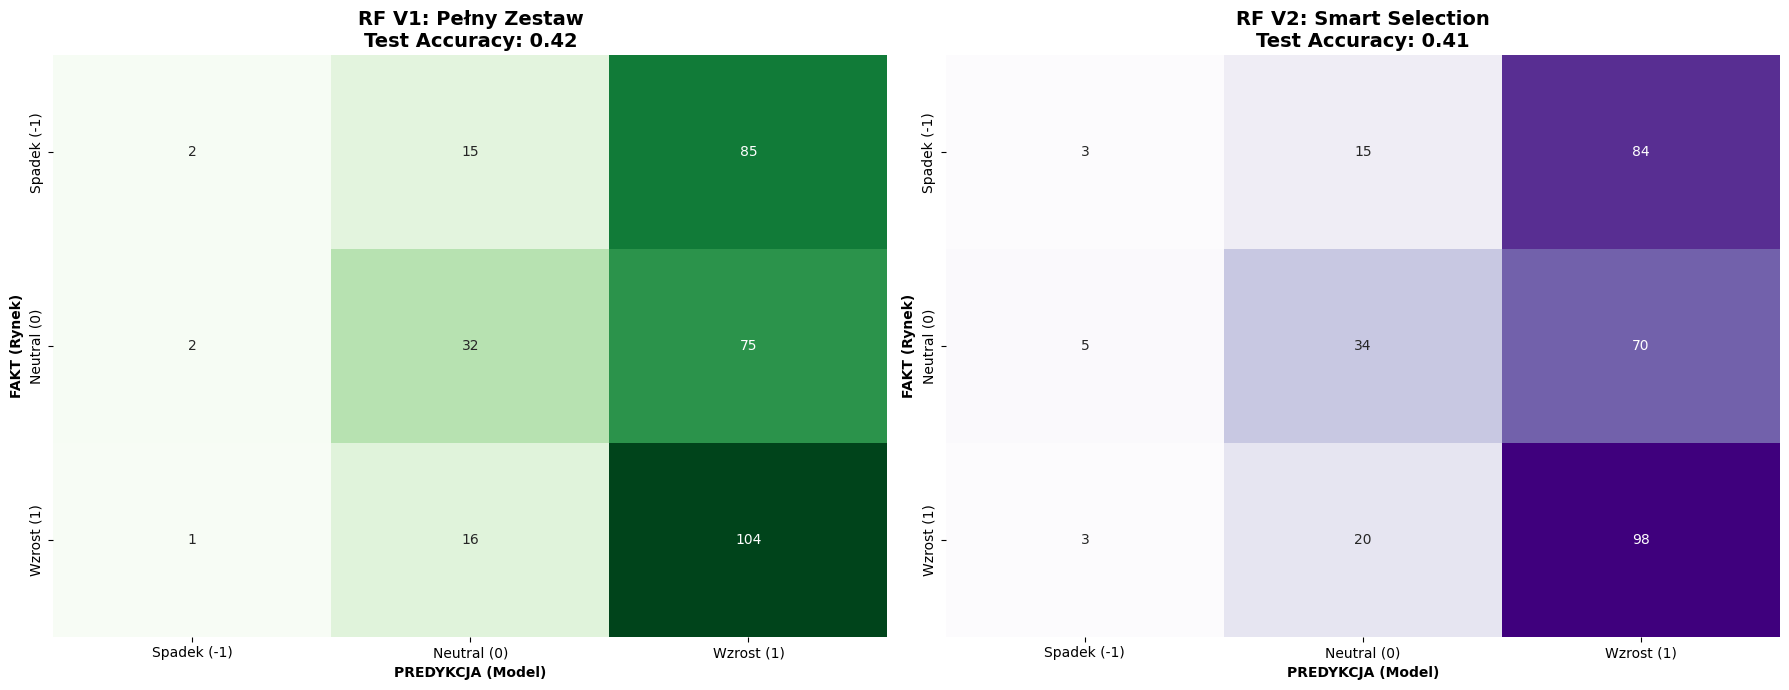


           ANALIZA OVERFITTINGU (Learning Curves)           


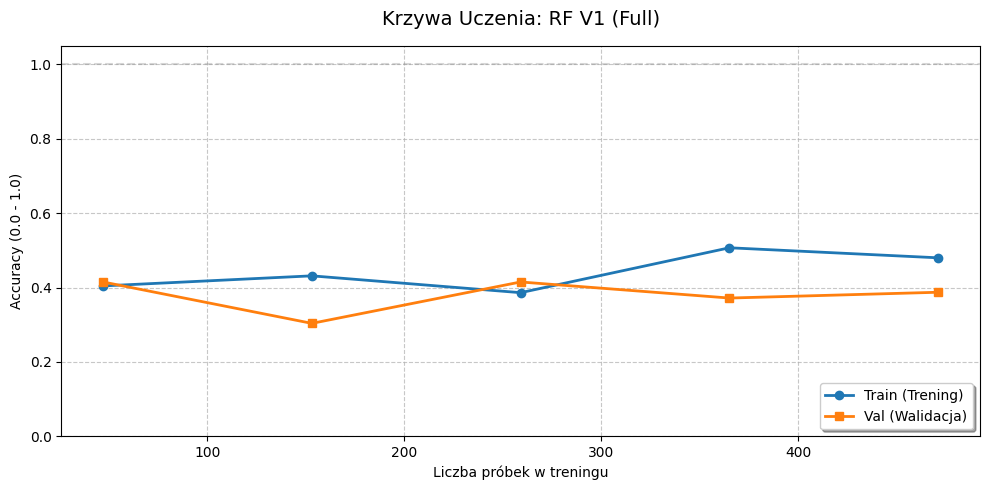

Ostatnie Accuracy - Train: 0.4798, Val: 0.3872
Gap (Overfitting): 0.0926


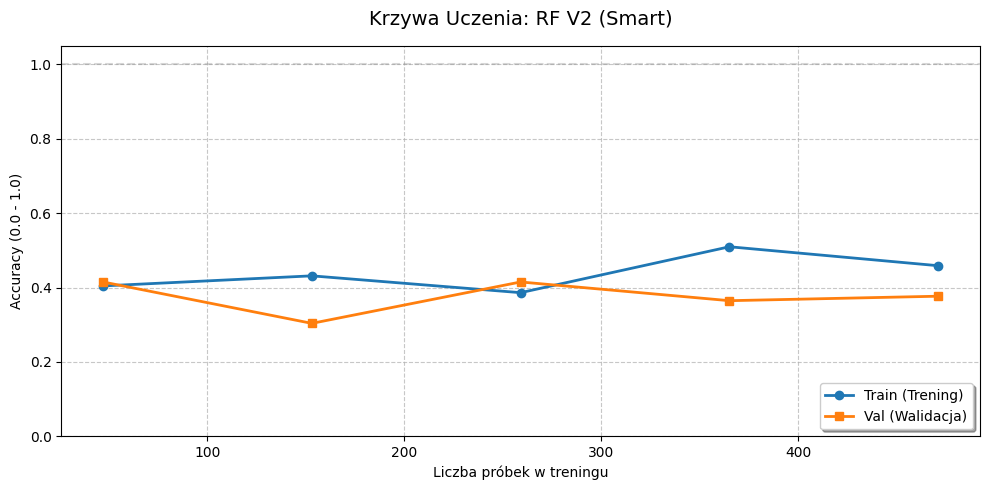

Ostatnie Accuracy - Train: 0.4586, Val: 0.3766
Gap (Overfitting): 0.0820

========================= RAPORT V1 (Full) =========================
              precision    recall  f1-score   support

 Spadek (-1)       0.40      0.02      0.04       102
 Neutral (0)       0.51      0.29      0.37       109
  Wzrost (1)       0.39      0.86      0.54       121

    accuracy                           0.42       332
   macro avg       0.43      0.39      0.32       332
weighted avg       0.43      0.42      0.33       332


========================= RAPORT V2 (Smart) =========================
              precision    recall  f1-score   support

 Spadek (-1)       0.27      0.03      0.05       102
 Neutral (0)       0.49      0.31      0.38       109
  Wzrost (1)       0.39      0.81      0.53       121

    accuracy                           0.41       332
   macro avg       0.38      0.38      0.32       332
weighted avg       0.39      0.41      0.33       332



In [74]:
import numpy as np
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report
import matplotlib.pyplot as plt
import seaborn as sns

# --- 1. PRZYGOTOWANIE DANYCH (Format NumPy dla stabilności) ---
X_test_v1_np = X_test_v1.values if hasattr(X_test_v1, 'values') else X_test_v1
X_test_v2_np = X_test_v2.values if hasattr(X_test_v2, 'values') else X_test_v2
X_full_v1_np = X_full_v1 # Już złączone wcześniej przez np.concatenate
X_full_v2_np = X_full_v2

# --- 2. PREDYKCJE ---
y_pred_v1 = rf_v1_final.predict(X_test_v1_np)
y_pred_v2 = rf_v2_final.predict(X_test_v2_np)

# --- 3. DASHBOARD PARAMETRÓW POD WYKRESY ---
print("\n" + "="*60)
print(f"{'PARAMETRY OPTYMALNE RF':^60}")
print("="*60)
print(f"{'PARAMETR':<25} | {'MODEL V1 (Full)':<20} | {'MODEL V2 (Smart)':<20}")
print("-"*60)

val_v1 = f"{study_rf_v1.best_value:.4f}" if 'study_rf_v1' in locals() else "N/A"
val_v2 = f"{study_rf_v2.best_value:.4f}" if 'study_rf_v2' in locals() else "N/A"

print(f"{'Liczba cech':<25} | {rf_v1_final.n_features_in_:<20} | {rf_v2_final.n_features_in_:<20}")
print(f"{'Best F1 Mean (CV)':<25} | {val_v1:<20} | {val_v2:<20}")
print(f"{'n_estimators':<25} | {rf_v1_final.n_estimators:<20} | {rf_v2_final.n_estimators:<20}")
print(f"{'max_depth':<25} | {str(rf_v1_final.max_depth):<20} | {str(rf_v2_final.max_depth):<20}")
print(f"{'min_samples_leaf':<25} | {rf_v1_final.min_samples_leaf:<20} | {rf_v2_final.min_samples_leaf:<20}")
print(f"{'max_samples':<25} | {str(rf_v1_final.max_samples):<20} | {str(rf_v2_final.max_samples):<20}")
print("="*60)

# --- 4. WIZUALIZACJA: CONFUSION MATRIX ---
fig, ax = plt.subplots(1, 2, figsize=(18, 7))
target_names = ['Spadek (-1)', 'Neutral (0)', 'Wzrost (1)']

for i, (y_p, title, cmap) in enumerate([(y_pred_v1, 'RF V1: Pełny Zestaw', 'Greens'), 
                                        (y_pred_v2, 'RF V2: Smart Selection', 'Purples')]):
    cm = confusion_matrix(y_test_encoded, y_p)
    sns.heatmap(cm, annot=True, fmt='d', cmap=cmap, ax=ax[i],
                xticklabels=target_names, yticklabels=target_names, cbar=False)
    acc = accuracy_score(y_test_encoded, y_p)
    ax[i].set_title(f"{title}\nTest Accuracy: {acc:.2f}", fontsize=14, fontweight='bold')
    ax[i].set_xlabel('PREDYKCJA (Model)', fontweight='bold')
    ax[i].set_ylabel('FAKT (Rynek)', fontweight='bold')

plt.tight_layout()
plt.show()

# --- 5. ANALIZA OVERFITTINGU (KRZYWE UCZENIA) ---
# Używamy X_full i y_full, bo modele finalne były trenowane na połączonym zbiorze Train+Val
print("\n" + "="*60)
print(f"{'ANALIZA OVERFITTINGU (Learning Curves)':^60}")
print("="*60)
plot_overfitting_analysis(rf_v1_final, X_full_v1, y_full, "Krzywa Uczenia: RF V1 (Full)")
plot_overfitting_analysis(rf_v2_final, X_full_v2, y_full, "Krzywa Uczenia: RF V2 (Smart)")

# --- 6. RAPORTY KLASYFIKACJI ---
print("\n" + "="*25 + " RAPORT V1 (Full) " + "="*25)
print(classification_report(y_test_encoded, y_pred_v1, target_names=target_names, zero_division=0))

print("\n" + "="*25 + " RAPORT V2 (Smart) " + "="*25)
print(classification_report(y_test_encoded, y_pred_v2, target_names=target_names, zero_division=0))